In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from region import Region
from functions import Functions

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 147,-68,-64]
shelf_comparison_extent = [139,146,-67,-66]

elevation = elevation_.sel(latitude = slice(shelf_comparison_extent[2], shelf_comparison_extent[3]), longitude = slice(shelf_comparison_extent[0],shelf_comparison_extent[1]))


In [6]:
ds = xr.open_dataset('profiles_full.nc')
cdict = pickle.load(open('cdict.pkl','rb'))
en4 = xr.open_dataset('en4_analysis.nc')

In [7]:
en4['month'] = en4.time.dt.month
en4['year'] = en4.time.dt.year
en4_shelf = en4.sel(lat=slice(shelf_comparison_extent[2],shelf_comparison_extent[3]),lon=slice(shelf_comparison_extent[0],shelf_comparison_extent[1])).mean(['lat','lon'])

In [8]:
ds_shelf = ds.where(ds.elevation
                     > -1000,drop=True)

seasons_meop = fns.get_seasons(ds_shelf)
seasons_en4 = fns.get_seasons(en4_shelf)

In [9]:
# choose depth to average over
zz = 300

max_depth = ds_shelf.pres.where(~np.isnan(ds_shelf.temp)).max(dim="pres")
ds_z = ds_shelf.where(max_depth > zz,drop=True).sel(pres=slice(0,zz))
en4_z = en4_shelf.sel(depth=slice(0,zz))


In [10]:
ds

<xarray.Dataset> Size: 73MB
Dimensions:    (time: 3015, pres: 501)
Coordinates:
  * time       (time) datetime64[ns] 24kB 2004-10-28T21:36:00.003089408 ... 2...
    lon        (time) float64 24kB ...
    lat        (time) float64 24kB ...
  * pres       (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp       (time, pres) float64 12MB ...
    psal       (time, pres) float64 12MB ...
    mld        (time) float64 24kB ...
    elevation  (time) float64 24kB -1.332e+03 -3.497e+03 ... -105.2 -133.7
    month      (time) float64 24kB ...
    year       (time) float64 24kB ...
    asal       (time, pres) float64 12MB ...
    ctemp      (time, pres) float64 12MB ...
    rho        (time, pres) float64 12MB ...
    sigma0     (time, pres) float64 12MB ...
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [11]:
n_min = 10

ds_zz = ds_z.mean('pres')
en4_zz = en4_z.mean('depth')
mon_mean_ = ds_zz.resample({'time':'MS'}).mean()
mon_std = ds_zz.resample({'time':'MS'}).std()
mon_count = ds_zz.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean_.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [12]:
mon_mean

<xarray.Dataset> Size: 3kB
Dimensions:    (time: 34)
Coordinates:
  * time       (time) datetime64[ns] 272B 2007-02-01 2007-03-01 ... 2024-02-01
Data variables:
    temp       (time) float64 272B -1.229 -1.707 -1.706 ... -1.876 -1.836 -1.489
    psal       (time) float64 272B 34.19 34.2 34.39 34.44 ... 34.61 34.57 34.24
    mld        (time) float64 272B 46.53 176.9 132.3 92.39 ... nan nan nan nan
    elevation  (time) float64 272B -309.7 -347.2 -580.7 ... -347.6 -367.2 -429.3
    month      (time) float64 272B 2.0 3.0 4.0 5.0 12.0 ... 5.0 6.0 8.0 9.0 2.0
    year       (time) float64 272B 2.007e+03 2.007e+03 ... 2.023e+03 2.024e+03
    asal       (time) float64 272B 34.35 34.36 34.55 34.61 ... 34.77 34.74 34.41
    ctemp      (time) float64 272B -1.229 -1.707 -1.706 ... -1.876 -1.836 -1.488
    rho        (time) float64 272B 1.028e+03 1.028e+03 ... 1.029e+03 1.028e+03
    sigma0     (time) float64 272B 27.51 27.53 27.69 27.73 ... 27.87 27.84 27.56
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [13]:
en4_shelf_likemeop = en4_shelf.broadcast_like(mon_mean.time)
en4_zz_likemeop = en4_zz.drop_dims('bnds').interp(time=mon_mean.time)

In [14]:
cli_count = mon_mean.groupby('time.month').count()

cli_mean = mon_mean.groupby('time.month').mean()
cli_std = mon_mean.groupby('time.month').std()

cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
cli_std = cli_std.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [15]:
df=mon_mean.groupby('time.month').where(cli_count.temp > 1).to_dataframe()

In [16]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

In [17]:
df

,temp,psal,mld,elevation,year,asal,ctemp,rho,sigma0,month
time,,,,,,,,,,
2007-02-01,-1.229250,34.185879,46.528351,-309.666778,2007.0,34.352610,-1.229428,1028.241890,27.508077,2
2007-03-01,-1.707331,34.195567,176.871454,-347.168367,2007.0,34.362357,-1.706907,1028.267026,27.531132,3
2007-04-01,-1.705647,34.385890,132.280334,-580.687588,2007.0,34.553536,-1.705614,1028.421112,27.685557,4
2007-05-01,-1.751470,34.438657,92.386809,-324.917772,2007.0,34.606625,-1.751395,1028.465843,27.729981,5
2007-12-01,-1.525625,34.459863,45.456780,-579.877737,2007.0,34.628101,-1.525721,1028.471656,27.739886,12
2008-01-01,-1.340376,34.385823,32.460386,-628.379498,2008.0,34.553605,-1.340677,1028.405624,27.673255,1
2008-02-01,-1.413840,34.374128,123.959627,-358.895633,2008.0,34.541803,-1.414239,1028.401382,27.667042,2
2008-03-01,-1.684626,34.396723,208.395390,-482.806670,2008.0,34.564492,-1.684530,1028.429643,27.694003,3
2008-04-01,-1.791717,34.478461,183.864221,-389.864222,2008.0,34.646638,-1.791561,1028.499784,27.763535,4


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this ob

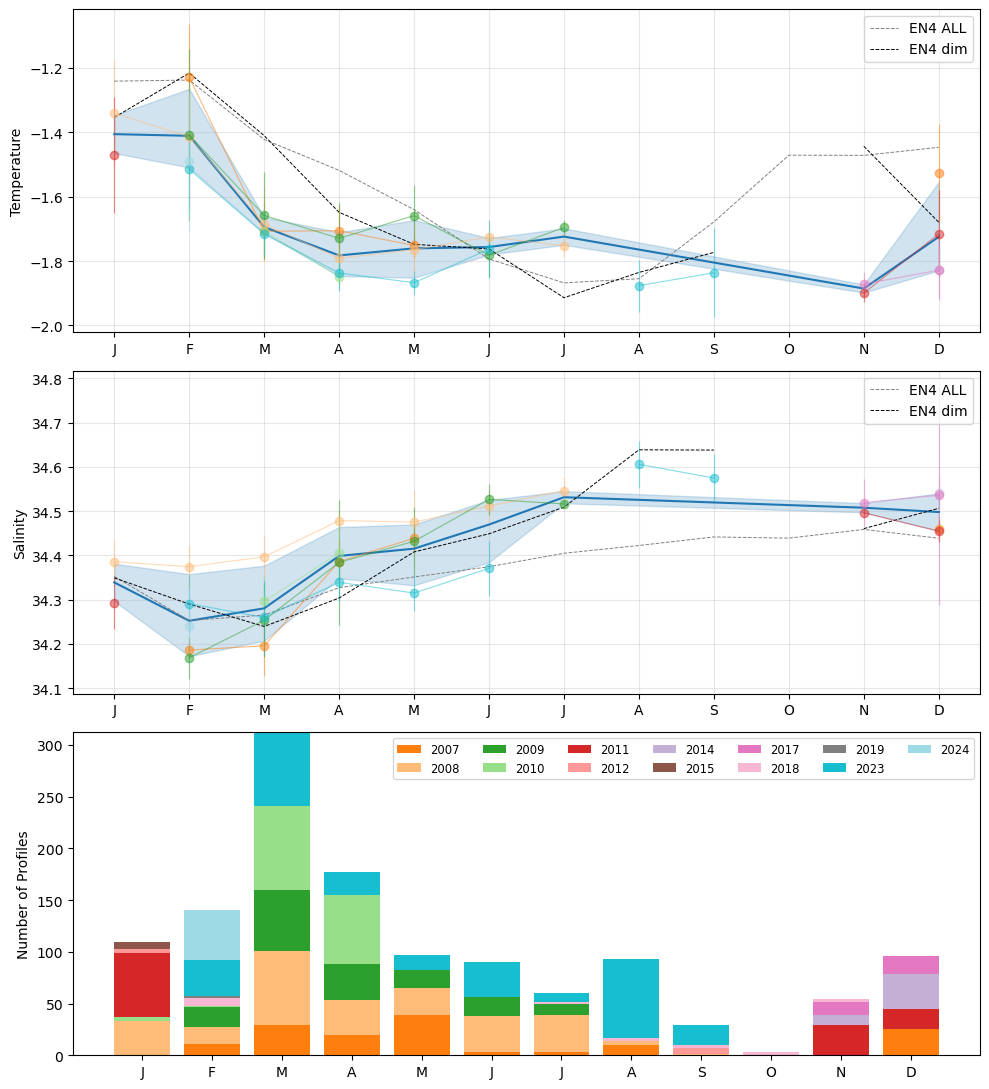

In [18]:
# # plot to demonstrate types of variailty
# dscrop = ds_400.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2008,1,1)))
# dscropmon = dscrop.groupby('time.month').mean()
# dscropmonstd = dscrop.groupby('time.month').std()

# fig,axs = plt.subplots(2,1,figsize=(10,5))
# ax=axs[0]
# ax.scatter(dscrop.month,dscrop.temp)
# ax.errorbar(dscropmon.month,dscropmon.temp,yerr=dscropmonstd.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# ax=axs[1]
# ax.scatter(mon_mean.month,mon_mean.temp)
# ax.errorbar(cli_mean.month,cli_mean.temp,yerr=cli_std.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# plt.tight_layout()

# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.where(mon_count.temp).groupby('time.year').count()


ax=axs[0]
cx=axs[1]
bx=axs[2]

for y_da in moc_year.year:
    y = y_da.item()
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)

    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        # temperature
        ax.errorbar(clim.month,clim.temp,yerr=clis.temp,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])
        
        # salinity
        cx.errorbar(clim.month,clim.psal,yerr=clis.psal,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])

    # histogram
    year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    if len(year_count) > 0:
        year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
        if y > 2007:
            bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
            bottom = bottom + year_count
        else:
            bx.bar(month_values, year_count,color=cdict[y],label=str(y))
            bottom = year_count.copy()
        

#ax.legend(loc='best',fontsize=2)
bx.legend(ncol=7,fontsize='small')
bx.set_ylabel('Number of Profiles')
bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="temp", errorbar=("pi",90), ax=ax, 
)

en4_mean = en4_zz.temperature.groupby('time.month').mean()-273.15
en4_lm_mean = en4_zz_likemeop.temperature.groupby('time.month').mean().broadcast_like(month_values)-273.15

en4_unce = en4_zz.temperature_uncertainty.groupby('time.month').mean()
en4_lm_unce = en4_zz_likemeop.temperature_uncertainty.groupby('time.month').mean().broadcast_like(month_values)

ax.plot(month_values,en4_mean,label='EN4 ALL',ls='--',linewidth=0.7,c='grey')
#ax.fill_between(month_values, en4_mean - en4_unce, en4_mean + en4_unce, alpha=0.3)

ax.plot(month_values,en4_lm_mean,label='EN4 dim',ls='--',linewidth=0.7,c='k')
#ax.fill_between(month_values, en4_lm_mean - en4_lm_unce, en4_lm_mean + en4_lm_unce, alpha=0.3)
        
sns.lineplot(
    data=df,
    x="month", y="psal", errorbar=("pi",90), ax=cx
)

en4_mean = en4_zz.salinity.groupby('time.month').mean()
en4_lm_mean = en4_zz_likemeop.salinity.groupby('time.month').mean().broadcast_like(month_values)

en4_unce = en4_zz.salinity_uncertainty.groupby('time.month').mean()
en4_lm_unce = en4_zz_likemeop.salinity_uncertainty.groupby('time.month').mean().broadcast_like(month_values)

cx.plot(month_values,en4_mean,label='EN4 ALL',ls='--',linewidth=0.7,c='grey')
#ax.fill_between(month_values, en4_mean - en4_unce, en4_mean + en4_unce, alpha=0.3)

cx.plot(month_values,en4_lm_mean,label='EN4 dim',ls='--',linewidth=0.7,c='k')
#ax.fill_between(month_values, en4_lm_mean - en4_lm_unce, en4_lm_mean + en4_lm_unce, alpha=0.3)

ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('Temperature')
ax.set_xlabel(None)
ax.legend()

cx.grid(alpha=0.3)
cx.set_xticks(np.arange(1,13),labels=month_labels)
cx.set_ylabel('Salinity')
cx.set_xlabel(None)
cx.legend()

plt.tight_layout()



In [19]:
mon_mean = ds_shelf.resample({'time':'MS'}).mean()
mon_std = ds_shelf.resample({'time':'MS'}).std()
mon_quants = ds_shelf.resample({'time':'MS'}).quantile([0.1,0.9])
mon_iqr = mon_quants.sel(quantile=0.9) - mon_quants.sel(quantile=0.1)
mon_count = ds_shelf.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)
mon_iqr = mon_iqr.where(mon_count > n_min, drop=True)

cli_count = mon_mean.groupby('time.month').count().broadcast_like(cli_count)
cli_mean = mon_mean.groupby('time.month').mean().broadcast_like(cli_count)
cli_std = mon_mean.groupby('time.month').std().broadcast_like(cli_count)
cli_quants = mon_mean.drop_vars(['month']).groupby('time.month').quantile([0.1,0.9]).broadcast_like(cli_count)
cli_iqr = cli_quants.sel(quantile=0.9) - cli_quants.sel(quantile=0.1).broadcast_like(cli_count)




# make sure all months used have more than n profiles
# cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
# cli_std = cli_std.where(cli_count.temp >1,drop=True)
# cli_iqr = cli_iqr.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

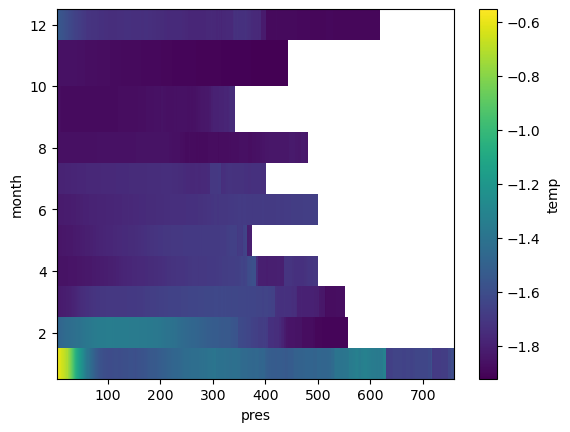

In [20]:
cli_mean.temp.plot()

NameError: name 'Xe' is not defined

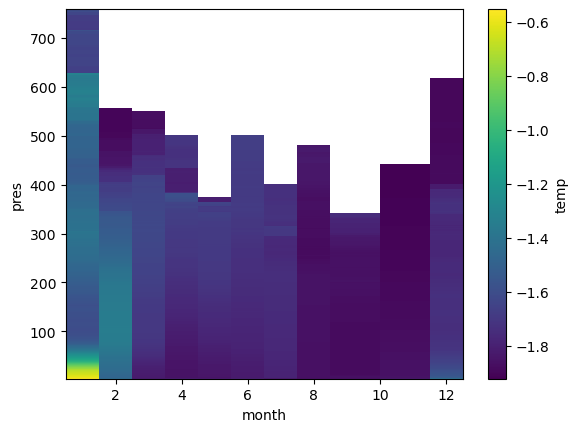

In [21]:
cli_mean.temp.plot(x='month',y='pres')

plt.gca().pcolor(Xe,Ye, Z.T, #hatch_layer,
        alpha=0.01,
        hatch='xx'
    )

In [ ]:
mask = (cli_count.temp < 2) | np.isnan(cli_count.temp)

hatch_layer = xr.where(mask, 1, np.nan)

Z = hatch_layer.values

Xe = edges(hatch_layer['month'])
Ye = edges(hatch_layer['pres'])

Xe

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5, 10. , 11.5,
       12.5])

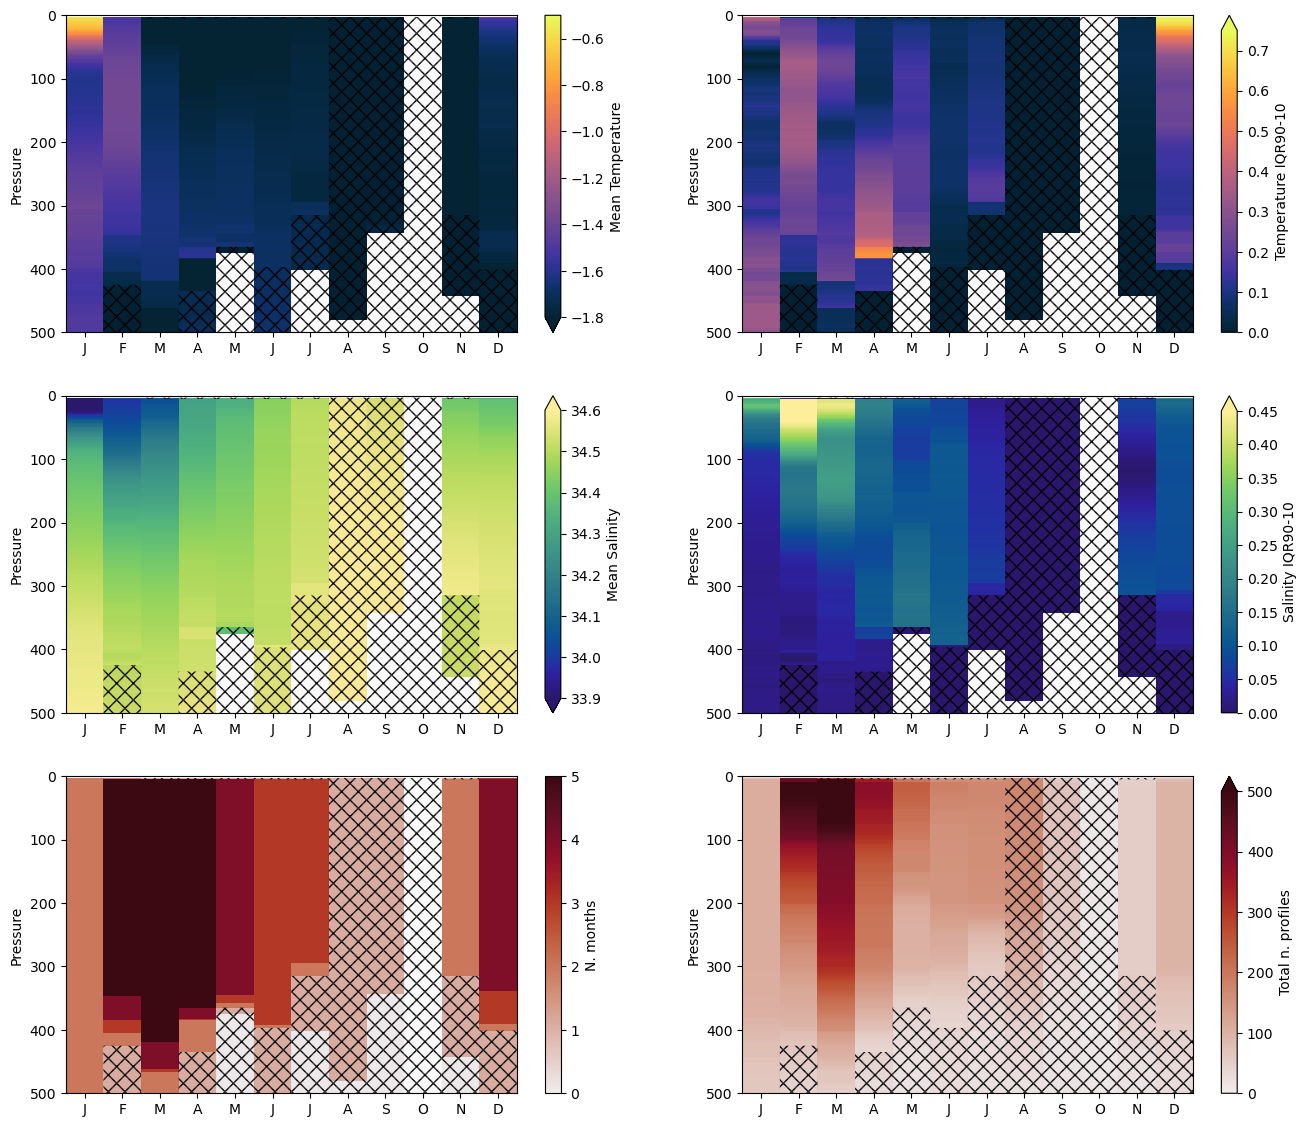

In [ ]:
fig, ax = plt.subplots(3,2,figsize=(16,14))

cli_count = cli_count.broadcast_like(month_values)
cli_mean = cli_mean.broadcast_like(month_values)
cli_iqr = cli_iqr.broadcast_like(month_values)

mask = (cli_count.temp < 2) | np.isnan(cli_count.temp)

hatch_layer = xr.where(mask, 1, np.nan)

Z = hatch_layer.values

def edges(coord):
    c = coord.values
    d = np.diff(c)/2
    return np.concatenate(([c[0]-d[0]], c[:-1]+d, [c[-1]+d[-1]]))

Xe = edges(hatch_layer['month'])
Ye = edges(hatch_layer['pres'])

def presvmonth(ax,data,label,cmap,c1=None,c2=None):
    im=data.plot(ax=ax,x='month',y='pres',cmap=cmap,vmin=c1,vmax=c2)

    ax.pcolor(Xe, Ye, Z.T, #hatch_layer,
        alpha=0.01,
        hatch='xx'
    )
        
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    im.colorbar.set_label(label)
    ax.set_xticks(np.arange(1,13),labels=month_labels)
    ax.set_xlabel(None)
    ax.set_ylim([500,0])


presvmonth(ax[0][0],cli_mean.temp,'Mean Temperature',cmap=cmocean.cm.thermal,c1=-1.8,c2=-0.5)
presvmonth(ax[0][1],cli_iqr.temp,'Temperature IQR90-10',cmocean.cm.thermal,c1=0,c2=0.75)

presvmonth(ax[1][0],cli_mean.psal,'Mean Salinity',cmap=cmocean.cm.haline,c1=33.9,c2=34.6)
presvmonth(ax[1][1],cli_iqr.psal,'Salinity IQR90-10',cmocean.cm.haline,c1=0,c2=0.45)

presvmonth(ax[2][0],cli_count.temp,'N. months',cmocean.cm.amp,c1=0,c2=5)
presvmonth(ax[2][1],mon_count.psal.groupby('time.month').sum(),'Total n. profiles',cmocean.cm.amp,c1=0,c2=500)


In [ ]:
max_depth

<xarray.DataArray 'pres' (time: 2544)> Size: 20kB
array([498., 430., 724., ...,  46., 180., 268.], shape=(2544,))
Coordinates:
  * time     (time) datetime64[ns] 20kB 2007-02-20T23:29:59.000002 ... 2024-0...
    lon      (time) float64 20kB 140.0 140.0 140.0 140.0 ... 140.0 139.8 139.8
    lat      (time) float64 20kB -66.56 -66.58 -66.66 ... -66.65 -66.61 -66.61

In [ ]:
a=ds_shelf.where(ds_shelf.year==y,drop=True)
maxz = a.pres.where(~np.isnan(a.temp)).max(dim="pres")
a.where(maxz > 100,drop=True)#.sel(pres=slice(0,100))

<xarray.Dataset> Size: 5MB
Dimensions:    (time: 216, pres: 501)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2024-02-06T03:10:00 ... 2024-02-18T2...
    lon        (time) float64 2kB 140.0 140.1 140.1 140.1 ... 140.0 139.8 139.8
    lat        (time) float64 2kB -66.65 -66.58 -66.64 ... -66.63 -66.61 -66.61
  * pres       (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp       (time, pres) float64 866kB nan nan -1.592 -1.558 ... nan nan nan
    psal       (time, pres) float64 866kB nan nan 33.93 33.93 ... nan nan nan
    mld        (time) float64 2kB nan nan nan nan nan ... nan nan nan nan nan
    elevation  (time) float64 2kB -180.0 -218.4 -476.0 ... -212.6 -105.2 -133.7
    month      (time) float64 2kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
    year       (time) float64 2kB 2.024e+03 2.024e+03 ... 2.024e+03 2.024e+03
    asal       (time, pres) float64 866kB nan nan 34.09 34.1 ... nan nan nan nan
    ctemp      (time, pres) float64 866kB nan nan -1.588 -1.554 ... nan nan nan
    rho        (time, pres) float64 866kB nan nan 1.027e+03 ... nan nan nan
    sigma0     (time, pres) float64 866kB nan nan 27.31 27.31 ... nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

/tmp/ipykernel_2879714/217945412.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_2879714/217945412.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_2879714/217945412.py:10: UserWarning: *c* argument looks like a singl

/tmp/ipykernel_2879714/217945412.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_2879714/217945412.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_2879714/217945412.py:10: UserWarning: *c* argument looks like a singl

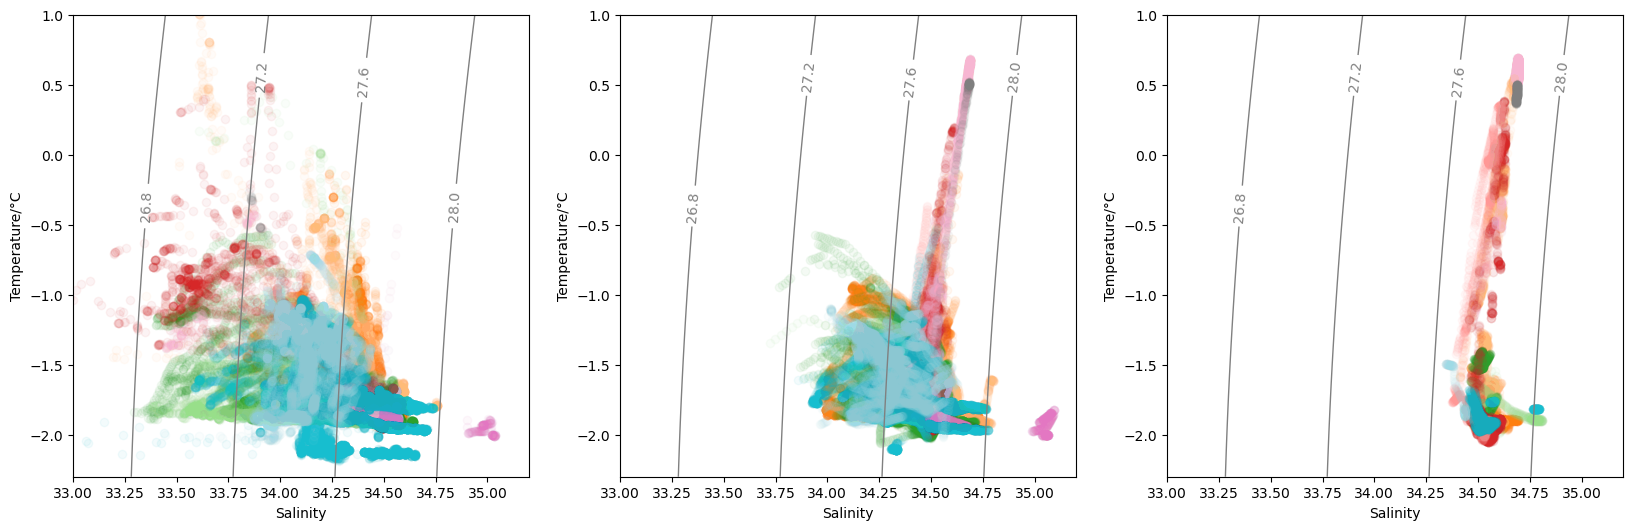

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(20,6))

ims=[]
def ts_plot(ax,z1,z2):
    for y in cdict.keys():
        data = ds_shelf.where(ds_shelf.year==y,drop=True)
        maxz = data.pres.where(~np.isnan(data.temp)).max(dim="pres")
        data = data.where(maxz > z2,drop=True).sel(pres=slice(z1,z2))
        if not len(data.time) ==0:
            ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y],label=str(y.item())))

            

    tlim=[-2.3,1]
    slim=[33,35.2]
    temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
    cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax.set_xlim(slim)
    ax.set_ylim(tlim)
    ax.set_ylabel('Temperature/°C')
    ax.set_xlabel('Salinity')

ts_plot(ax[0],0,100)
ts_plot(ax[1],100,300)
ts_plot(ax[2],300,600)
